# 🤖 03 — Model Training & Selection
## FIFA World Cup 2026 Prediction Project

Notebook ini melatih dan membandingkan beberapa model:
1. **Logistic Regression** — baseline
2. **Random Forest** — ensemble ML
3. **XGBoost** — gradient boosting
4. **Poisson Regression** — prediksi skor
5. **Ensemble** — kombinasi model terbaik

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import log_loss, accuracy_score, confusion_matrix, classification_report
from sklearn.calibration import calibration_curve
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '..')
from src.models import (
    PoissonMatchPredictor, ClassificationPredictor, 
    EnsemblePredictor, evaluate_model
)

plt.style.use('seaborn-v0_8-darkgrid')
DATA_DIR = Path('../data')
OUTPUT_DIR = Path('../outputs')

## 1. Load Feature Matrix

In [2]:
# Load feature matrix dari notebook 02
df = pd.read_csv(OUTPUT_DIR / 'predictions' / 'feature_matrix.csv')
df['Date'] = pd.to_datetime(df['Date'])

print(f'Feature matrix: {df.shape}')
print(f'Date range: {df["Date"].min()} to {df["Date"].max()}')

# Feature columns (exclude metadata & target)
meta_cols = ['Date', 'Home Team', 'Away Team', 'Tournament', 
             'Home Goals', 'Away Goals', 'result']
feature_cols = [c for c in df.columns if c not in meta_cols]
print(f'\nFeature columns ({len(feature_cols)}): {feature_cols}')

# Drop rows with NaN features
df_clean = df.dropna(subset=feature_cols).copy()
print(f'\nClean rows: {len(df_clean)} (dropped {len(df) - len(df_clean)} with NaN)')

Feature matrix: (25316, 29)
Date range: 2000-01-04 00:00:00 to 2026-06-08 00:00:00

Feature columns (22): ['elo_home', 'elo_away', 'elo_diff', 'home_win_rate', 'home_avg_goals_scored', 'home_avg_goals_conceded', 'home_goal_diff_avg', 'away_win_rate', 'away_avg_goals_scored', 'away_avg_goals_conceded', 'away_goal_diff_avg', 'form_diff', 'goal_diff_form', 'home_wc_appearances', 'away_wc_appearances', 'home_wc_titles', 'away_wc_titles', 'wc_exp_diff', 'wc_titles_diff', 'is_wc', 'is_friendly', 'is_qualifier']

Clean rows: 25316 (dropped 0 with NaN)


## 2. Train/Validation Split (Time-based)

In [3]:
# Time-based split: Train ≤ 2018, Validation = 2019-2022
train_mask = df_clean['Date'] < '2019-01-01'
val_mask = df_clean['Date'] >= '2019-01-01'

X_train = df_clean.loc[train_mask, feature_cols]
y_train = df_clean.loc[train_mask, 'result']
X_val = df_clean.loc[val_mask, feature_cols]
y_val = df_clean.loc[val_mask, 'result']

print(f'Training set:   {X_train.shape[0]} matches (up to 2018)')
print(f'Validation set: {X_val.shape[0]} matches (2019-2022)')
print(f'\nTrain result distribution:')
print(y_train.value_counts().rename({0: 'Away Win', 1: 'Draw', 2: 'Home Win'}))
print(f'\nVal result distribution:')
print(y_val.value_counts().rename({0: 'Away Win', 1: 'Draw', 2: 'Home Win'}))

Training set:   18164 matches (up to 2018)
Validation set: 7152 matches (2019-2022)

Train result distribution:
result
Home Win    8761
Away Win    5135
Draw        4268
Name: count, dtype: int64

Val result distribution:
result
Home Win    3427
Away Win    2097
Draw        1628
Name: count, dtype: int64


## 3. Model Training

In [4]:
# 3.1 Logistic Regression (Baseline)
print('Training Logistic Regression...')
lr_model = ClassificationPredictor(model_type='logistic_regression', C=1.0)
lr_model.fit(X_train, y_train, feature_columns=feature_cols)

lr_proba_val = lr_model.predict_proba(X_val)
lr_eval = evaluate_model(y_val.values, lr_proba_val, 'Logistic Regression')
print(f'  → {lr_eval}')

Training Logistic Regression...


  → {'model': 'Logistic Regression', 'log_loss': 0.865, 'accuracy': 0.6023, 'brier_score': np.float64(0.1694)}


In [5]:
# 3.2 Random Forest
print('Training Random Forest...')
rf_model = ClassificationPredictor(
    model_type='random_forest',
    n_estimators=300, max_depth=12, min_samples_leaf=15
)
rf_model.fit(X_train, y_train, feature_columns=feature_cols)

rf_proba_val = rf_model.predict_proba(X_val)
rf_eval = evaluate_model(y_val.values, rf_proba_val, 'Random Forest')
print(f'  → {rf_eval}')

Training Random Forest...


  → {'model': 'Random Forest', 'log_loss': 0.8706, 'accuracy': 0.6022, 'brier_score': np.float64(0.1704)}


In [6]:
# 3.3 XGBoost
print('Training XGBoost...')
xgb_model = ClassificationPredictor(
    model_type='xgboost',
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8
)
xgb_model.fit(X_train, y_train, feature_columns=feature_cols)

xgb_proba_val = xgb_model.predict_proba(X_val)
xgb_eval = evaluate_model(y_val.values, xgb_proba_val, 'XGBoost')
print(f'  → {xgb_eval}')

Training XGBoost...


  → {'model': 'XGBoost', 'log_loss': 0.8798, 'accuracy': 0.597, 'brier_score': np.float64(0.1724)}


In [7]:
# 3.4 Poisson Regression
print('Training Poisson Regression...')
poisson_model = PoissonMatchPredictor(max_goals=8)
poisson_model.fit(
    X_train, 
    df_clean.loc[train_mask, 'Home Goals'],
    df_clean.loc[train_mask, 'Away Goals'],
    feature_columns=feature_cols
)

poisson_proba_val = poisson_model.predict_proba(X_val)
poisson_eval = evaluate_model(y_val.values, poisson_proba_val, 'Poisson Regression')
print(f'  → {poisson_eval}')

Training Poisson Regression...


  → {'model': 'Poisson Regression', 'log_loss': 1.828, 'accuracy': 0.1689, 'brier_score': np.float64(0.3424)}


In [8]:
# 3.5 Ensemble (weighted average of best models)
print('Building Ensemble...')
ensemble = EnsemblePredictor(
    models=[rf_model, xgb_model, lr_model],
    weights=[0.4, 0.4, 0.2]  # Will be adjusted based on performance
)

ens_proba_val = ensemble.predict_proba(X_val)
ens_eval = evaluate_model(y_val.values, ens_proba_val, 'Ensemble')
print(f'  → {ens_eval}')

Building Ensemble...
  → {'model': 'Ensemble', 'log_loss': 0.8674, 'accuracy': 0.6033, 'brier_score': np.float64(0.1699)}


## 4. Model Comparison

Model Comparison (sorted by Log Loss — lower is better):
              model  log_loss  accuracy  brier_score
Logistic Regression    0.8650    0.6023       0.1694
           Ensemble    0.8674    0.6033       0.1699
      Random Forest    0.8706    0.6022       0.1704
            XGBoost    0.8798    0.5970       0.1724
 Poisson Regression    1.8280    0.1689       0.3424


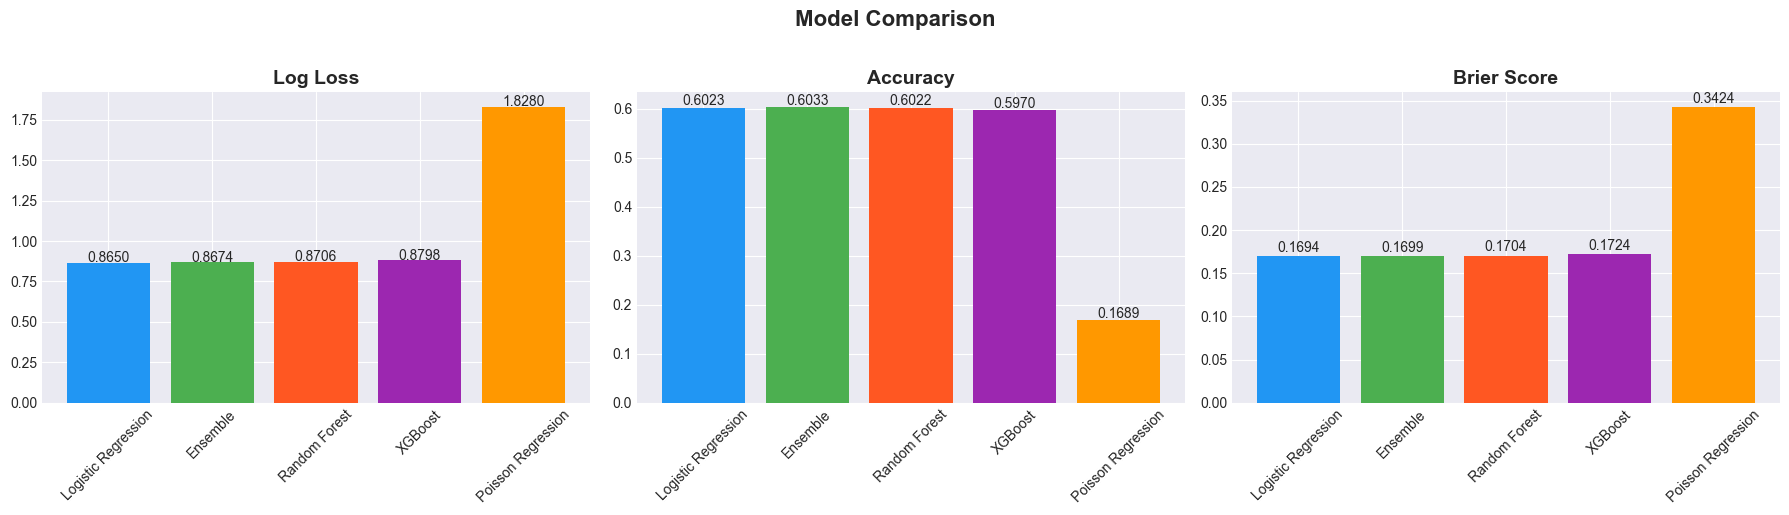

In [9]:
# Compare all models
results = pd.DataFrame([lr_eval, rf_eval, xgb_eval, poisson_eval, ens_eval])
results = results.sort_values('log_loss')

print('Model Comparison (sorted by Log Loss — lower is better):')
print('=' * 60)
print(results.to_string(index=False))

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800']

for i, metric in enumerate(['log_loss', 'accuracy', 'brier_score']):
    ax = axes[i]
    bars = ax.bar(results['model'], results[metric], color=colors[:len(results)])
    ax.set_title(metric.replace('_', ' ').title(), fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    
    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', fontsize=10)

plt.suptitle('Model Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/03_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Feature Importance

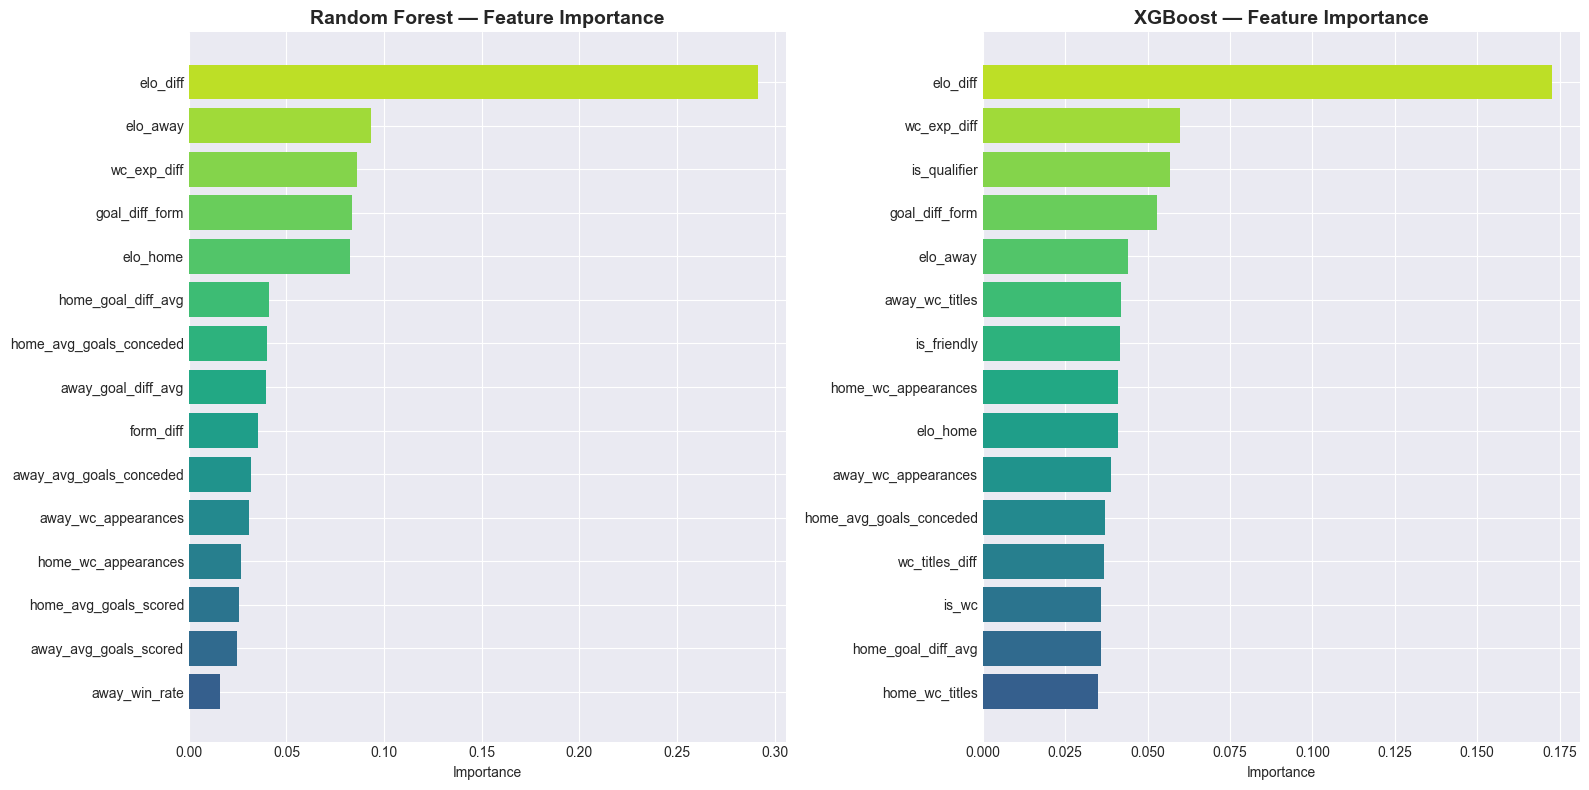

In [10]:
# Feature importance dari Random Forest dan XGBoost
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for i, (model, name) in enumerate([(rf_model, 'Random Forest'), (xgb_model, 'XGBoost')]):
    importance = model.feature_importance()
    top15 = importance.head(15)
    
    axes[i].barh(top15.index[::-1], top15.values[::-1], 
                 color=plt.cm.viridis(np.linspace(0.3, 0.9, 15)))
    axes[i].set_title(f'{name} — Feature Importance', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('../outputs/figures/03_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Confusion Matrix

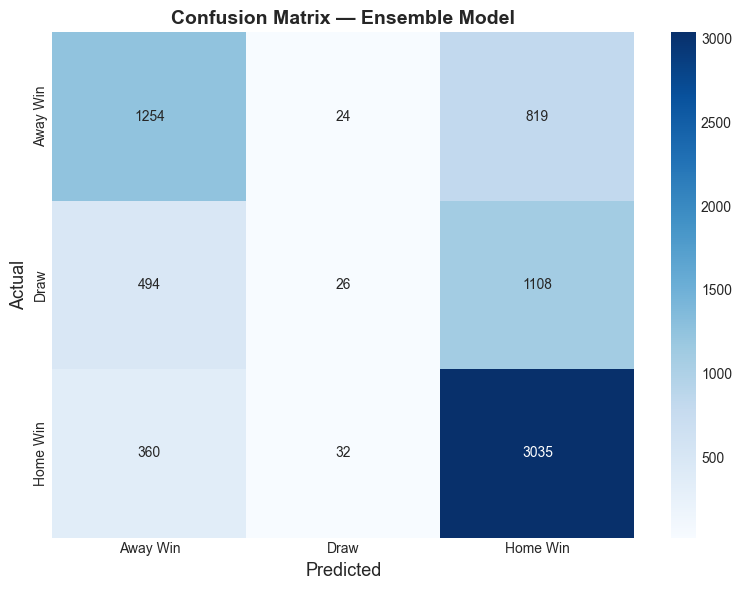


Classification Report:
              precision    recall  f1-score   support

    Away Win       0.59      0.60      0.60      2097
        Draw       0.32      0.02      0.03      1628
    Home Win       0.61      0.89      0.72      3427

    accuracy                           0.60      7152
   macro avg       0.51      0.50      0.45      7152
weighted avg       0.54      0.60      0.53      7152



In [11]:
# Confusion matrix untuk model terbaik
# Gunakan ensemble sebagai default
best_proba = ens_proba_val
best_pred = best_proba.argmax(axis=1)

cm = confusion_matrix(y_val, best_pred)
labels = ['Away Win', 'Draw', 'Home Win']

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel('Predicted', fontsize=13)
ax.set_ylabel('Actual', fontsize=13)
ax.set_title('Confusion Matrix — Ensemble Model', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/03_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nClassification Report:')
print(classification_report(y_val, best_pred, target_names=labels))

## 7. Save Best Model

In [12]:
# Retrain best models on ALL data for final prediction
print('Retraining on full dataset for final predictions...')

X_full = df_clean[feature_cols]
y_full = df_clean['result']

# Retrain
rf_final = ClassificationPredictor(
    model_type='random_forest',
    n_estimators=300, max_depth=12, min_samples_leaf=15
)
rf_final.fit(X_full, y_full, feature_columns=feature_cols)

xgb_final = ClassificationPredictor(
    model_type='xgboost',
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8
)
xgb_final.fit(X_full, y_full, feature_columns=feature_cols)

lr_final = ClassificationPredictor(model_type='logistic_regression', C=1.0)
lr_final.fit(X_full, y_full, feature_columns=feature_cols)

final_ensemble = EnsemblePredictor(
    models=[rf_final, xgb_final, lr_final],
    weights=[0.4, 0.4, 0.2]
)

# Save model info and feature columns
import pickle
model_data = {
    'feature_cols': feature_cols,
    'rf_model': rf_final,
    'xgb_model': xgb_final,
    'lr_model': lr_final,
    'ensemble': final_ensemble,
    'validation_results': results.to_dict('records'),
}

with open(OUTPUT_DIR / 'predictions' / 'trained_models.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print('✅ Models trained and saved!')
print(f'   Feature columns: {len(feature_cols)}')
print(f'   Training samples: {len(X_full)}')
print('\nNext: 04_tournament_simulation.ipynb')

Retraining on full dataset for final predictions...


✅ Models trained and saved!
   Feature columns: 22
   Training samples: 25316

Next: 04_tournament_simulation.ipynb
